In [16]:
from pathlib import Path

import pandas as pd

from plot_bspoints import (
    build_bspoints_from_kline,
    plot_bspoints,
)


# ============================================================
# 1. GENERATE PRICE DATA AND BSP DATA
# ============================================================

data_path = Path("DataAPI/data/TQQQ_5M.csv")

start_time = pd.Timestamp("2020-01-01")
end_time = pd.Timestamp("2026-05-30")

price_df, bsp_df = build_bspoints_from_kline(
    data_path,
    code="TQQQ",
    freq="5m",
    start=start_time,
    end=end_time,
    max_klines=500,
    warmup_bars=500,
)


# ============================================================
# 2. VERIFY THE DATA
# ============================================================

print("price_df shape:", price_df.shape)
print("bsp_df shape:", bsp_df.shape)

print("\nprice_df columns:")
print(price_df.columns.tolist())

print("\nbsp_df columns:")
print(bsp_df.columns.tolist())

display(price_df.head())
display(bsp_df.head())

price_df shape: (306208, 12)
bsp_df shape: (39222, 66)

price_df columns:
['timestamp', 'Open', 'High', 'Low', 'Close', 'Volume', '_open', '_high', '_low', '_close', '_vol', 'day']

bsp_df columns:
['klu_idx', 'timestamp', 'klu_open', 'klu_high', 'klu_low', 'klu_close', 'klu_volume', 'bsp_type', 'bsp_types', 'is_buy', 'direction', 'bi_direction', 'segment_direction', 'is_segbsp', 'feat_divergence_rate', 'feat_bsp1_bi_amp', 'feat_bsp1_bi_klu_cnt', 'feat_bsp1_bi_amp_rate', 'feat_zs_cnt', 'feat_ppo', 'feat_bsp_bi_amp', 'feat_break_bi_amp', 'feat_break_bi_klu_cnt', 'feat_break_bi_amp_rate', 'feat_bi_amp', 'feat_bi_klu_cnt', 'feat_bi_amp_rate', 'feat_level', 'feat_bsp_type', 'macd_value', 'macd_diff', 'macd_dea', 'rsi', 'kdj_k', 'kdj_d', 'kdj_j', 'dmi_plus', 'dmi_minus', 'dmi_adx', 'price_change_pct', 'high_low_spread_pct', 'upper_shadow', 'lower_shadow', 'body_size', 'is_bullish_candle', 'snapshot_first_seen', 'snapshot_last_seen', 'feat_bsp2_retrace_rate', 'feat_bsp2_break_bi_amp', 'feat_

,timestamp,Open,High,Low,Close,Volume,_open,_high,_low,_close,_vol,day
0,2020-01-02 04:00:00,11.0150,11.0375,11.0150,11.0337,132864,11.0150,11.0375,11.0150,11.0337,132864.0,2020-01-02
1,2020-01-02 04:05:00,11.0375,11.0388,11.0375,11.0388,70984,11.0375,11.0388,11.0375,11.0388,70984.0,2020-01-02
2,2020-01-02 04:15:00,11.0563,11.0600,11.0563,11.0600,11200,11.0563,11.0600,11.0563,11.0600,11200.0,2020-01-02
3,2020-01-02 04:20:00,11.0575,11.0575,11.0512,11.0512,5472,11.0575,11.0575,11.0512,11.0512,5472.0,2020-01-02
4,2020-01-02 04:25:00,11.0525,11.0525,11.0525,11.0525,6400,11.0525,11.0525,11.0525,11.0525,6400.0,2020-01-02


,klu_idx,timestamp,klu_open,klu_high,klu_low,klu_close,klu_volume,bsp_type,bsp_types,is_buy,...,feat_bsp2s_break_bi_klu_cnt,feat_bsp2s_break_bi_amp_rate,feat_bsp2s_bi_amp,feat_bsp2s_bi_klu_cnt,feat_bsp2s_bi_amp_rate,feat_bsp2s_lv,feat_bsp3_zs_height,feat_bsp3_bi_amp,feat_bsp3_bi_klu_cnt,feat_bsp3_bi_amp_rate
0,500,2020-01-02 04:00:00,11.0150,11.0375,11.0150,11.0337,132864.0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,501,2020-01-02 04:05:00,11.0375,11.0388,11.0375,11.0388,70984.0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,502,2020-01-02 04:15:00,11.0563,11.0600,11.0563,11.0600,11200.0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,509,2020-01-02 04:50:00,11.0525,11.0625,11.0525,11.0625,5440.0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,510,2020-01-02 04:55:00,11.0650,11.0650,11.0650,11.0650,2400.0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
plot_output = Path("outputs/bspoints_TQQQ_5m_2020-2026.png")
excel_output = Path("outputs/bspoints_TQQQ_5m_2020-2026.xlsx")
plot_output.parent.mkdir(parents=True, exist_ok=True)
plot_bspoints(
    price_df,
    bsp_df,
    title="TQQQ 5min BSP points",
    output=plot_output,
    annotate=False,  # Shows BSP type, buy/sell, Bi direction and segment direction
    show_volume=False,
)
bsp_df.to_excel(
    excel_output,
    sheet_name="BSP Points",
    index=False,
)

In [18]:
# ============================================================
# 3. NORMALIZE PRICE COLUMNS
# ============================================================

price_df = price_df.copy()

column_mapping = {}

if "open" not in price_df.columns and "_open" in price_df.columns:
    column_mapping["_open"] = "open"

if "high" not in price_df.columns and "_high" in price_df.columns:
    column_mapping["_high"] = "high"

if "low" not in price_df.columns and "_low" in price_df.columns:
    column_mapping["_low"] = "low"

if "close" not in price_df.columns and "_close" in price_df.columns:
    column_mapping["_close"] = "close"

if column_mapping:
    price_df = price_df.rename(
        columns=column_mapping
    )

required_price_columns = {
    "timestamp",
    "open",
    "close",
}

missing_price_columns = (
    required_price_columns
    - set(price_df.columns)
)

if missing_price_columns:
    raise KeyError(
        "price_df is missing required columns: "
        f"{sorted(missing_price_columns)}"
    )

required_bsp_columns = {
    "timestamp",
    "direction",
    "bsp_type",
}

missing_bsp_columns = (
    required_bsp_columns
    - set(bsp_df.columns)
)

if missing_bsp_columns:
    raise KeyError(
        "bsp_df is missing required columns: "
        f"{sorted(missing_bsp_columns)}"
    )

price_df["timestamp"] = pd.to_datetime(
    price_df["timestamp"]
)

bsp_df["timestamp"] = pd.to_datetime(
    bsp_df["timestamp"]
)

print("Data is ready for backtesting.")

Data is ready for backtesting.


In [19]:
from CustomBuySellPoint import (
    SegBspStrategy,
    SegBspStrategyConfig,
)
from ModelStrategy import (
    BacktestChanConfig,
    run_bsp_backtest,
)
from Trade import RiskConfig, RiskManager


# ============================================================
# 4. CREATE STRATEGY
# ============================================================

strategy = SegBspStrategy(
    SegBspStrategyConfig(
        # Allow entries in both segment directions.
        entry_segment_directions=frozenset({
            "up",
            "down",
        }),

        entry_bsp_types=frozenset({
            "1",
            "1p",
            "2",
            "2s",
            "3a",
            "3b",
        }),

        sell_bsp_types=frozenset({
            "1",
            "1p",
            "2",
            "2s",
            "3a",
            "3b",
        }),

        # ====================================================
        # BUY LOOKBACK FOR EACH SEGMENT
        # ====================================================

        buy_lookback_bars_by_segment={
            "up": 10,
            "down": 15,
        },

        # ====================================================
        # REQUIRED BUY SIGNALS FOR EACH SEGMENT AND BSP TYPE
        # ====================================================

        required_buy_signals_by_segment={
            # Trend-following entry.
            "up": {
                "1": 1,
                "1p": 1,
                "2": 1,
                "2s": 1,
                "3a": 1,
                "3b": 1,
            },

            # Contrarian entry requires stronger confirmation.
            "down": {
                "1": 5,
                "1p": 5,
                "2": 5,
                "2s": 5,
                "3a": 10,
                "3b": 10,
            },
        },

        # ====================================================
        # SELL LOOKBACK BASED ON ENTRY SEGMENT
        # ====================================================

        sell_lookback_bars_by_entry_segment={
            "up": 20,
            "down": 10,
        },

        # ====================================================
        # REQUIRED SELL SIGNALS BASED ON ENTRY SEGMENT
        # ====================================================

        required_sell_signals_by_entry_segment={
            # Position originally opened in an up segment.
            "up": {
                "1": 15,
                "1p": 15,
                "2": 15,
                "2s": 15,
                "3a": 15,
                "3b": 15,
            },

            # Position originally opened in a down segment.
            # Exit more quickly if the reversal fails.
            "down": {
                "1": 1,
                "1p": 1,
                "2": 1,
                "2s": 1,
                "3a": 1,
                "3b": 1,
            },
        },

        # ====================================================
        # STRUCTURAL EXIT
        # ====================================================

        exit_segment_directions_by_entry_segment={
            # Up-segment entry exits if structure turns down.
            "up": frozenset({
                "down",
            }),

            # Down-segment entry is allowed to remain open
            # while the segment is still down.
            "down": frozenset(),
        },

        # Global fallback values.
        required_buy_signals=1,
        buy_lookback_bars=15,
        required_sell_signals=5,
        sell_lookback_bars=10,

        exit_on_down_segment=True,
        allow_unconfirmed_entry=False,
        reset_sell_count_on_buy=True,
        reset_buy_count_on_sell=True,
        position_fraction=1.0,
    )
)

# ============================================================
# 5. RISK MANAGEMENT
# ============================================================

risk_manager = RiskManager(
    RiskConfig(
        stop_loss_pct=0.03,
        take_profit_pct=0.20,
        trailing_stop_pct=0.025,
        max_holding_bars=78 * 10,
    )
)


# ============================================================
# 6. BACKTEST CONFIGURATION
# ============================================================

backtest_config = BacktestChanConfig(
    initial_capital=100_000,
    fee_pct=0.000,
    slippage_pct=0.000,
    close_at_end=True,
)


# ============================================================
# 7. RUN BACKTEST
# ============================================================

result = run_bsp_backtest(
    price_df=price_df,
    bsp_df=bsp_df,
    strategy=strategy,
    config=backtest_config,
    risk_manager=risk_manager,
)


# ============================================================
# 8. DISPLAY RESULTS
# ============================================================

print("\nStrategy metrics:")

for name, value in result.metrics.items():
    print(f"{name}: {value}")

print("\nTrade count:", len(result.trades))

display(result.trades)
display(result.equity.tail())


Strategy metrics:
final_equity: 15166253.459945487
total_return: 150.66253459945486
max_drawdown: -0.2631945904460149
sharpe: 1.6826814564408947
closed_trades: 1011
win_rate: 0.5806132542037586
profit_factor: 1.6406921100280671

Trade count: 2022


,side,seen_idx,exec_idx,exec_px,reason,position_fraction,idx,px,raw_px,qty,fee,pnl,return_pct
0,buy,705,706,10.7900,5/5 type-1 buy-signal bars in 15-bar window; B...,1.0,706,10.7900,10.7900,9267.840593,0.0,NaN,NaN
1,sell,751,752,11.3012,1/1 type-2s sell-signal bars in 10-bar window ...,1.0,752,11.3012,11.3012,9267.840593,0.0,4737.720111,0.047377
2,buy,1224,1225,11.6813,5/5 type-1 buy-signal bars in 15-bar window; B...,1.0,1225,11.6813,11.6813,8966.272599,0.0,NaN,NaN
3,sell,1265,1266,11.7175,1/1 type-3a sell-signal bars in 10-bar window ...,1.0,1266,11.7175,11.7175,8966.272599,0.0,324.579068,0.003099
4,buy,1740,1741,11.9962,5/5 type-2s buy-signal bars in 15-bar window; ...,1.0,1741,11.9962,11.9962,8757.964954,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017,sell,303973,303974,74.6600,trailing_stop,1.0,303974,74.6600,74.6600,200452.954543,0.0,605367.922720,0.042155
2018,buy,304430,304431,75.3600,5/5 type-2s buy-signal bars in 15-bar window; ...,1.0,304431,75.3600,75.3600,198590.997694,0.0,NaN,NaN
2019,sell,304557,304558,74.7200,trailing_stop,1.0,304558,74.7200,74.7200,198590.997694,0.0,-127098.238524,-0.008493
2020,buy,304815,304816,72.9400,1/1 type-2 buy-signal bars in 10-bar window; B...,1.0,304816,72.9400,72.9400,203437.336820,0.0,NaN,NaN


,timestamp,bar_index,equity,position
306203,2026-05-29 19:35:00,306203,1.516625e+07,0
306204,2026-05-29 19:40:00,306204,1.516625e+07,0
306205,2026-05-29 19:45:00,306205,1.516625e+07,0
306206,2026-05-29 19:50:00,306206,1.516625e+07,0
306207,2026-05-29 19:55:00,306207,1.516625e+07,0


In [21]:
# ============================================================
# 9. SAVE COMPLETE RESULT TO EXCEL
# ============================================================

from dataclasses import asdict
from pathlib import Path
import json

import pandas as pd


# ------------------------------------------------------------
# OUTPUT PATH
# ------------------------------------------------------------

output_dir = Path(
    "outputs/strategy_backtest"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

excel_output = (
    output_dir
    / "TQQQ_5m_strategy_result.xlsx"
)


# ------------------------------------------------------------
# METRICS SHEET
# ------------------------------------------------------------

metrics_df = pd.DataFrame(
    [
        {
            "metric": metric_name,
            "value": metric_value,
        }
        for metric_name, metric_value
        in result.metrics.items()
    ]
)


# ------------------------------------------------------------
# TRADE/FILL SHEET
# ------------------------------------------------------------

trades_df = result.trades.copy()

if not trades_df.empty:
    # Determine which column contains the execution bar index.
    if "idx" in trades_df.columns:
        execution_index_column = "idx"

    elif "exec_idx" in trades_df.columns:
        execution_index_column = "exec_idx"

    else:
        execution_index_column = None

    # Add execution timestamps using price_df.
    if execution_index_column is not None:

        def get_execution_timestamp(value):
            if pd.isna(value):
                return pd.NaT

            index = int(value)

            if (
                index < 0
                or index >= len(price_df)
            ):
                return pd.NaT

            return pd.to_datetime(
                price_df.iloc[index]["timestamp"]
            )

        trades_df[
            "execution_timestamp"
        ] = trades_df[
            execution_index_column
        ].map(
            get_execution_timestamp
        )

    # Add the signal-discovery timestamp.
    if "seen_idx" in trades_df.columns:

        def get_signal_timestamp(value):
            if pd.isna(value):
                return pd.NaT

            index = int(value)

            if (
                index < 0
                or index >= len(price_df)
            ):
                return pd.NaT

            return pd.to_datetime(
                price_df.iloc[index]["timestamp"]
            )

        trades_df[
            "signal_timestamp"
        ] = trades_df[
            "seen_idx"
        ].map(
            get_signal_timestamp
        )

    # Put the important columns first.
    preferred_trade_columns = [
        "side",
        "signal_timestamp",
        "execution_timestamp",
        "seen_idx",
        "exec_idx",
        "idx",
        "raw_px",
        "px",
        "qty",
        "fee",
        "reason",
        "pnl",
        "return_pct",
    ]

    ordered_trade_columns = [
        column
        for column in preferred_trade_columns
        if column in trades_df.columns
    ]

    remaining_trade_columns = [
        column
        for column in trades_df.columns
        if column not in ordered_trade_columns
    ]

    trades_df = trades_df[
        ordered_trade_columns
        + remaining_trade_columns
    ]


# ------------------------------------------------------------
# COMPLETED TRADES SHEET
# ------------------------------------------------------------

completed_trades_rows = []

if not trades_df.empty:
    current_buy = None

    for _, trade in trades_df.iterrows():
        side = str(
            trade.get("side", "")
        ).lower()

        if side == "buy":
            current_buy = trade

        elif (
            side == "sell"
            and current_buy is not None
        ):
            entry_price = float(
                current_buy.get(
                    "px",
                    current_buy.get(
                        "raw_px",
                        float("nan"),
                    ),
                )
            )

            exit_price = float(
                trade.get(
                    "px",
                    trade.get(
                        "raw_px",
                        float("nan"),
                    ),
                )
            )

            quantity = float(
                trade.get(
                    "qty",
                    current_buy.get(
                        "qty",
                        0.0,
                    ),
                )
            )

            entry_fee = float(
                current_buy.get(
                    "fee",
                    0.0,
                )
            )

            exit_fee = float(
                trade.get(
                    "fee",
                    0.0,
                )
            )

            gross_pnl = (
                exit_price
                - entry_price
            ) * quantity

            net_pnl = (
                gross_pnl
                - entry_fee
                - exit_fee
            )

            return_pct = (
                exit_price
                / entry_price
                - 1.0
                if entry_price != 0
                else float("nan")
            )

            entry_timestamp = current_buy.get(
                "execution_timestamp",
                pd.NaT,
            )

            exit_timestamp = trade.get(
                "execution_timestamp",
                pd.NaT,
            )

            if (
                pd.notna(entry_timestamp)
                and pd.notna(exit_timestamp)
            ):
                holding_minutes = (
                    pd.to_datetime(
                        exit_timestamp
                    )
                    - pd.to_datetime(
                        entry_timestamp
                    )
                ).total_seconds() / 60.0

            else:
                holding_minutes = float("nan")

            completed_trades_rows.append(
                {
                    "entry_signal_timestamp":
                        current_buy.get(
                            "signal_timestamp",
                            pd.NaT,
                        ),

                    "entry_timestamp":
                        entry_timestamp,

                    "exit_signal_timestamp":
                        trade.get(
                            "signal_timestamp",
                            pd.NaT,
                        ),

                    "exit_timestamp":
                        exit_timestamp,

                    "entry_price":
                        entry_price,

                    "exit_price":
                        exit_price,

                    "quantity":
                        quantity,

                    "entry_fee":
                        entry_fee,

                    "exit_fee":
                        exit_fee,

                    "total_fees":
                        entry_fee + exit_fee,

                    "gross_pnl":
                        gross_pnl,

                    "net_pnl":
                        net_pnl,

                    "return_pct":
                        return_pct,

                    "holding_minutes":
                        holding_minutes,

                    "entry_reason":
                        current_buy.get(
                            "reason",
                            "",
                        ),

                    "exit_reason":
                        trade.get(
                            "reason",
                            "",
                        ),
                }
            )

            current_buy = None

completed_trades_df = pd.DataFrame(
    completed_trades_rows
)


# ------------------------------------------------------------
# EXIT-REASON SUMMARY
# ------------------------------------------------------------

if (
    not trades_df.empty
    and "side" in trades_df.columns
    and "reason" in trades_df.columns
):
    exit_reason_df = (
        trades_df.loc[
            trades_df["side"].eq("sell"),
            "reason",
        ]
        .value_counts(
            dropna=False
        )
        .rename_axis(
            "exit_reason"
        )
        .reset_index(
            name="count"
        )
    )

else:
    exit_reason_df = pd.DataFrame(
        columns=[
            "exit_reason",
            "count",
        ]
    )


# ------------------------------------------------------------
# EQUITY SHEET
# ------------------------------------------------------------

equity_df = result.equity.copy()

if not equity_df.empty:
    equity_df["timestamp"] = pd.to_datetime(
        equity_df["timestamp"]
    )

    equity_df = equity_df.sort_values(
        "timestamp"
    ).reset_index(drop=True)

    equity_df["equity_return_pct"] = (
        equity_df["equity"]
        / float(
            backtest_config.initial_capital
        )
        - 1.0
    )

    equity_df["running_max_equity"] = (
        equity_df["equity"].cummax()
    )

    equity_df["drawdown_pct"] = (
        equity_df["equity"]
        / equity_df["running_max_equity"]
        - 1.0
    )


# ------------------------------------------------------------
# PRICE DATA SHEET
# ------------------------------------------------------------

price_export_df = price_df.copy()

if "timestamp" in price_export_df.columns:
    price_export_df["timestamp"] = (
        pd.to_datetime(
            price_export_df["timestamp"]
        )
    )


# ------------------------------------------------------------
# BSP POINTS SHEET
# ------------------------------------------------------------

bsp_export_df = bsp_df.copy()

if "timestamp" in bsp_export_df.columns:
    bsp_export_df["timestamp"] = (
        pd.to_datetime(
            bsp_export_df["timestamp"]
        )
    )


# ------------------------------------------------------------
# STRATEGY CONFIGURATION SHEET
# ------------------------------------------------------------

strategy_config_dict = asdict(
    strategy.config
)

strategy_config_rows = []

for config_name, config_value in (
    strategy_config_dict.items()
):
    if isinstance(
        config_value,
        (
            dict,
            list,
            tuple,
            set,
            frozenset,
        ),
    ):
        serializable_value = json.dumps(
            config_value,
            ensure_ascii=False,
            default=lambda value: (
                sorted(value)
                if isinstance(
                    value,
                    (
                        set,
                        frozenset,
                    ),
                )
                else str(value)
            ),
        )

    else:
        serializable_value = config_value

    strategy_config_rows.append(
        {
            "parameter": config_name,
            "value": serializable_value,
        }
    )

strategy_config_df = pd.DataFrame(
    strategy_config_rows
)


# ------------------------------------------------------------
# RISK CONFIGURATION SHEET
# ------------------------------------------------------------

risk_config_df = pd.DataFrame(
    [
        {
            "parameter": name,
            "value": value,
        }
        for name, value
        in asdict(
            risk_manager.config
        ).items()
    ]
)


# ------------------------------------------------------------
# BACKTEST CONFIGURATION SHEET
# ------------------------------------------------------------

backtest_config_df = pd.DataFrame(
    [
        {
            "parameter": name,
            "value": value,
        }
        for name, value
        in asdict(
            backtest_config
        ).items()
    ]
)


# ------------------------------------------------------------
# WRITE ONE EXCEL WORKBOOK
# ------------------------------------------------------------

with pd.ExcelWriter(
    excel_output,
) as writer:
    metrics_df.to_excel(
        writer,
        sheet_name="Metrics",
        index=False,
    )

    trades_df.to_excel(
        writer,
        sheet_name="Fills",
        index=False,
    )

    completed_trades_df.to_excel(
        writer,
        sheet_name="Completed Trades",
        index=False,
    )

    exit_reason_df.to_excel(
        writer,
        sheet_name="Exit Reasons",
        index=False,
    )

    equity_df.to_excel(
        writer,
        sheet_name="Equity",
        index=False,
    )

    bsp_export_df.to_excel(
        writer,
        sheet_name="BSP Points",
        index=False,
    )

    price_export_df.to_excel(
        writer,
        sheet_name="Price Data",
        index=False,
    )

    strategy_config_df.to_excel(
        writer,
        sheet_name="Strategy Config",
        index=False,
    )

    risk_config_df.to_excel(
        writer,
        sheet_name="Risk Config",
        index=False,
    )

    backtest_config_df.to_excel(
        writer,
        sheet_name="Backtest Config",
        index=False,
    )


print(
    "Excel result saved:"
)

print(
    excel_output.resolve()
)

Excel result saved:
C:\Users\TonyTang\Documents\chan.py\outputs\strategy_backtest\TQQQ_5m_strategy_result.xlsx


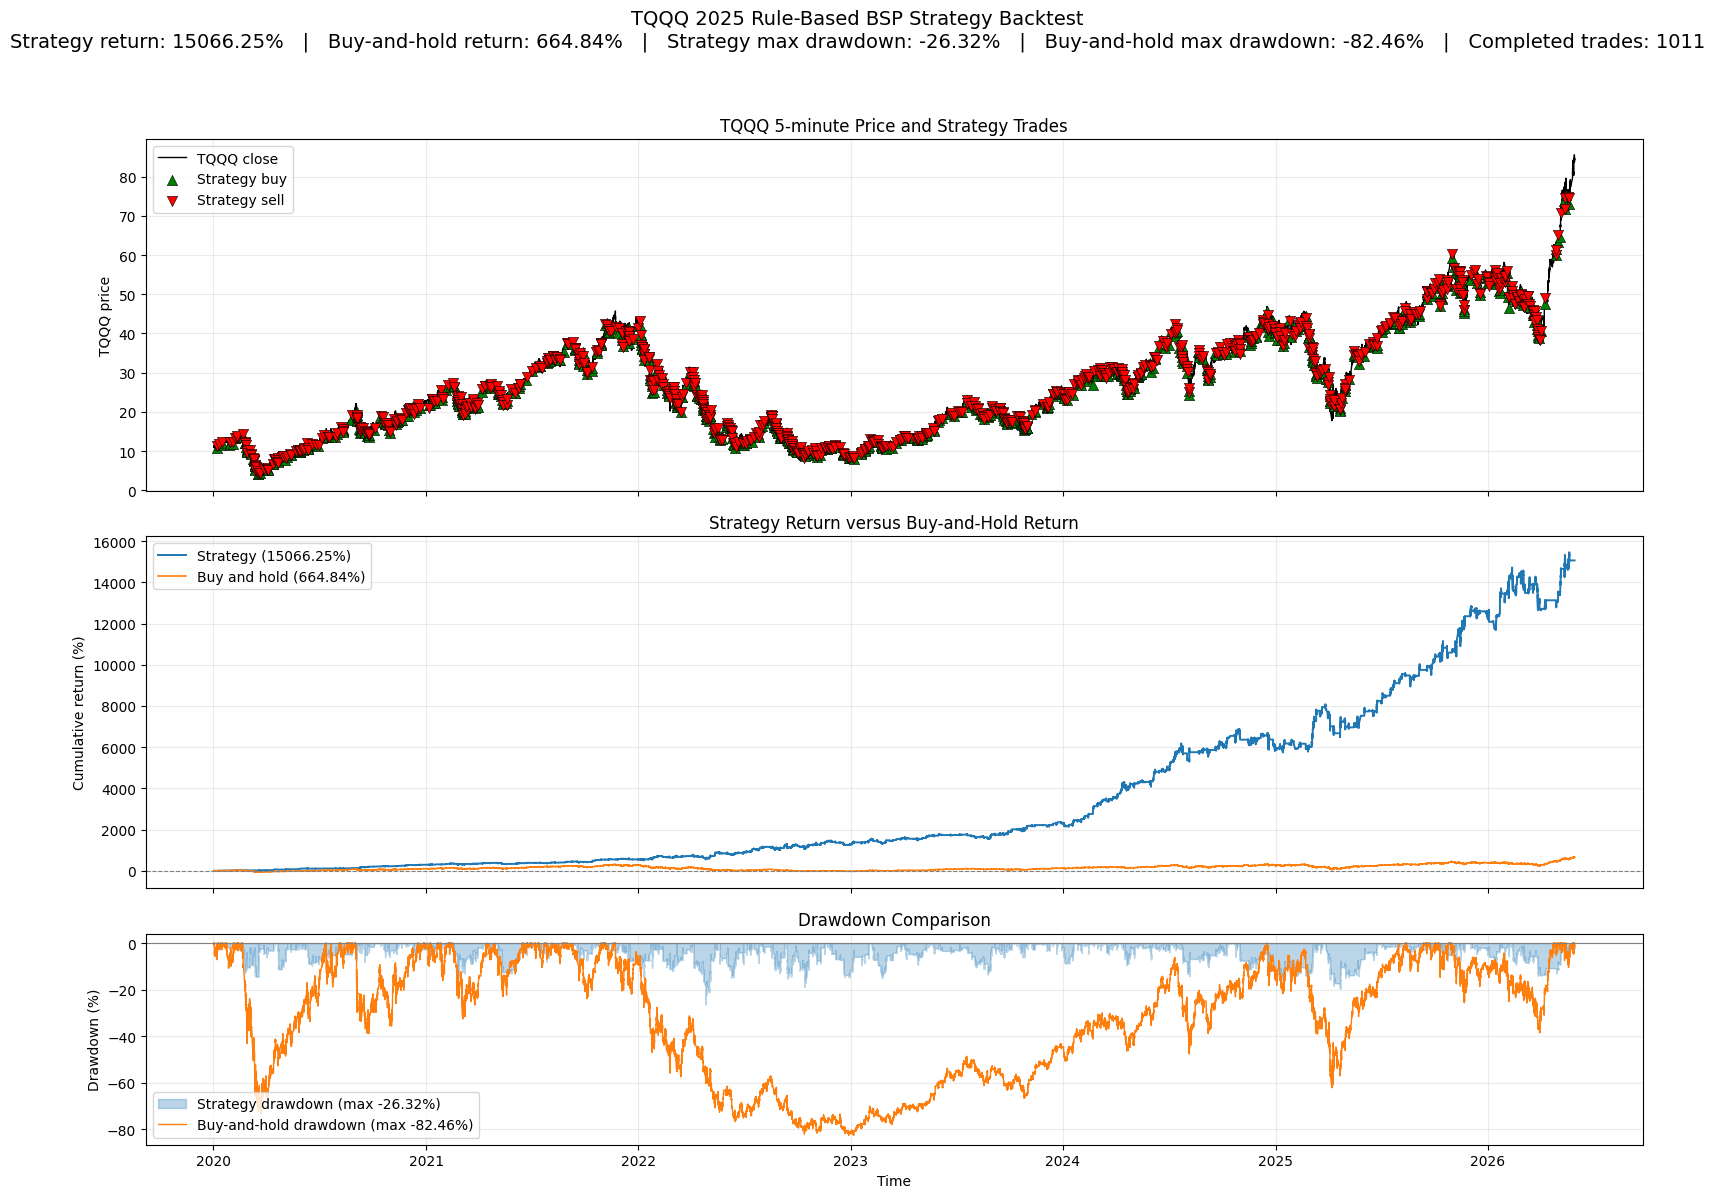

Comparison plot saved: C:\Users\TonyTang\Documents\chan.py\outputs\testable_strategy\TQQQ_2024\TQQQ_strategy_vs_buy_hold_2025.png


In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# OUTPUT LOCATION
# ============================================================

output_dir = Path(
    "outputs/testable_strategy/TQQQ_2024"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

comparison_plot_output = (
    output_dir
    / "TQQQ_strategy_vs_buy_hold_2025.png"
)


# ============================================================
# PREPARE PRICE DATA
# ============================================================

plot_price = price_df.copy()

plot_price["timestamp"] = pd.to_datetime(
    plot_price["timestamp"]
)

plot_price = (
    plot_price
    .sort_values("timestamp")
    .drop_duplicates(
        subset=["timestamp"],
        keep="last",
    )
    .reset_index(drop=True)
)

if "close" in plot_price.columns:
    close_column = "close"
elif "_close" in plot_price.columns:
    close_column = "_close"
elif "Close" in plot_price.columns:
    close_column = "Close"
else:
    raise KeyError(
        "Cannot find close, _close, or Close "
        "in price_df"
    )

plot_price[close_column] = pd.to_numeric(
    plot_price[close_column],
    errors="coerce",
)

plot_price = plot_price.dropna(
    subset=[close_column]
).reset_index(drop=True)


# ============================================================
# PREPARE STRATEGY EQUITY
# ============================================================

strategy_equity = result.equity.copy()

strategy_equity["timestamp"] = pd.to_datetime(
    strategy_equity["timestamp"]
)

strategy_equity = (
    strategy_equity
    .sort_values("timestamp")
    .drop_duplicates(
        subset=["timestamp"],
        keep="last",
    )
    .reset_index(drop=True)
)


# ============================================================
# CALCULATE COMPARABLE RETURNS
# ============================================================

initial_capital = float(
    backtest_config.initial_capital
)

plot_price["buy_hold_equity"] = (
    initial_capital
    * plot_price[close_column]
    / float(plot_price[close_column].iloc[0])
)

plot_price["buy_hold_return_pct"] = (
    plot_price["buy_hold_equity"]
    / initial_capital
    - 1.0
) * 100.0

strategy_equity["strategy_return_pct"] = (
    strategy_equity["equity"]
    / initial_capital
    - 1.0
) * 100.0


# ============================================================
# ALIGN PRICE AND STRATEGY RESULTS
# ============================================================

comparison = plot_price[
    [
        "timestamp",
        close_column,
        "buy_hold_equity",
        "buy_hold_return_pct",
    ]
].merge(
    strategy_equity[
        [
            "timestamp",
            "equity",
            "strategy_return_pct",
            "position",
        ]
    ],
    on="timestamp",
    how="left",
)

comparison[
    [
        "equity",
        "strategy_return_pct",
        "position",
    ]
] = comparison[
    [
        "equity",
        "strategy_return_pct",
        "position",
    ]
].ffill()

comparison["position"] = (
    comparison["position"]
    .fillna(0)
    .astype(int)
)


# ============================================================
# MAP TRADES TO TIMESTAMPS
# ============================================================

trades_for_plot = result.trades.copy()

if not trades_for_plot.empty:
    if "idx" in trades_for_plot.columns:
        execution_index_column = "idx"
    elif "exec_idx" in trades_for_plot.columns:
        execution_index_column = "exec_idx"
    else:
        execution_index_column = None

    if execution_index_column is not None:
        def index_to_timestamp(value):
            if pd.isna(value):
                return pd.NaT

            index = int(value)

            if index < 0 or index >= len(plot_price):
                return pd.NaT

            return plot_price.iloc[index]["timestamp"]

        trades_for_plot["execution_timestamp"] = (
            trades_for_plot[
                execution_index_column
            ].map(index_to_timestamp)
        )

        trades_for_plot = trades_for_plot.dropna(
            subset=["execution_timestamp"]
        )
    else:
        trades_for_plot[
            "execution_timestamp"
        ] = pd.NaT


# ============================================================
# CALCULATE DRAWDOWN
# ============================================================

strategy_running_max = comparison[
    "equity"
].cummax()

comparison["strategy_drawdown_pct"] = (
    comparison["equity"]
    / strategy_running_max
    - 1.0
) * 100.0

buy_hold_running_max = comparison[
    "buy_hold_equity"
].cummax()

comparison["buy_hold_drawdown_pct"] = (
    comparison["buy_hold_equity"]
    / buy_hold_running_max
    - 1.0
) * 100.0


# ============================================================
# SUMMARY VALUES
# ============================================================

strategy_final_return = float(
    comparison["strategy_return_pct"].iloc[-1]
)

buy_hold_final_return = float(
    comparison["buy_hold_return_pct"].iloc[-1]
)

strategy_max_drawdown = float(
    comparison["strategy_drawdown_pct"].min()
)

buy_hold_max_drawdown = float(
    comparison["buy_hold_drawdown_pct"].min()
)

completed_trades = int(
    result.metrics.get(
        "closed_trades",
        0,
    )
)


# ============================================================
# CREATE COMPARISON PLOT
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 12),
    sharex=True,
    gridspec_kw={
        "height_ratios": [2.0, 2.0, 1.2],
    },
)


# ------------------------------------------------------------
# PANEL 1: ORIGINAL TQQQ PRICE
# ------------------------------------------------------------

price_ax = axes[0]

price_ax.plot(
    comparison["timestamp"],
    comparison[close_column],
    color="black",
    linewidth=1.0,
    label="TQQQ close",
)

if not trades_for_plot.empty:
    buy_trades = trades_for_plot[
        trades_for_plot["side"].eq("buy")
    ]

    sell_trades = trades_for_plot[
        trades_for_plot["side"].eq("sell")
    ]

    if not buy_trades.empty:
        price_ax.scatter(
            buy_trades["execution_timestamp"],
            buy_trades["px"],
            marker="^",
            color="green",
            edgecolor="black",
            linewidth=0.4,
            s=55,
            label="Strategy buy",
            zorder=5,
        )

    if not sell_trades.empty:
        price_ax.scatter(
            sell_trades["execution_timestamp"],
            sell_trades["px"],
            marker="v",
            color="red",
            edgecolor="black",
            linewidth=0.4,
            s=55,
            label="Strategy sell",
            zorder=5,
        )

price_ax.set_title(
    "TQQQ 5-minute Price and Strategy Trades"
)

price_ax.set_ylabel("TQQQ price")
price_ax.grid(alpha=0.25)
price_ax.legend(loc="best")


# ------------------------------------------------------------
# PANEL 2: STRATEGY VS BUY-AND-HOLD RETURN
# ------------------------------------------------------------

return_ax = axes[1]

return_ax.plot(
    comparison["timestamp"],
    comparison["strategy_return_pct"],
    color="tab:blue",
    linewidth=1.4,
    label=(
        "Strategy "
        f"({strategy_final_return:.2f}%)"
    ),
)

return_ax.plot(
    comparison["timestamp"],
    comparison["buy_hold_return_pct"],
    color="tab:orange",
    linewidth=1.2,
    label=(
        "Buy and hold "
        f"({buy_hold_final_return:.2f}%)"
    ),
)

return_ax.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=0.8,
)

return_ax.set_title(
    "Strategy Return versus Buy-and-Hold Return"
)

return_ax.set_ylabel("Cumulative return (%)")
return_ax.grid(alpha=0.25)
return_ax.legend(loc="best")


# ------------------------------------------------------------
# PANEL 3: DRAWDOWN
# ------------------------------------------------------------

drawdown_ax = axes[2]

drawdown_ax.fill_between(
    comparison["timestamp"],
    comparison["strategy_drawdown_pct"],
    0,
    color="tab:blue",
    alpha=0.30,
    label=(
        "Strategy drawdown "
        f"(max {strategy_max_drawdown:.2f}%)"
    ),
)

drawdown_ax.plot(
    comparison["timestamp"],
    comparison["buy_hold_drawdown_pct"],
    color="tab:orange",
    linewidth=1.0,
    label=(
        "Buy-and-hold drawdown "
        f"(max {buy_hold_max_drawdown:.2f}%)"
    ),
)

drawdown_ax.axhline(
    0,
    color="gray",
    linewidth=0.8,
)

drawdown_ax.set_title(
    "Drawdown Comparison"
)

drawdown_ax.set_xlabel("Time")
drawdown_ax.set_ylabel("Drawdown (%)")
drawdown_ax.grid(alpha=0.25)
drawdown_ax.legend(loc="lower left")


# ============================================================
# FIGURE SUMMARY
# ============================================================

summary = (
    f"Strategy return: {strategy_final_return:.2f}%   |   "
    f"Buy-and-hold return: {buy_hold_final_return:.2f}%   |   "
    f"Strategy max drawdown: {strategy_max_drawdown:.2f}%   |   "
    f"Buy-and-hold max drawdown: {buy_hold_max_drawdown:.2f}%   |   "
    f"Completed trades: {completed_trades}"
)

fig.suptitle(
    "TQQQ 2025 Rule-Based BSP Strategy Backtest\n"
    + summary,
    fontsize=14,
    y=0.995,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.965]
)

fig.savefig(
    comparison_plot_output,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    f"Comparison plot saved: "
    f"{comparison_plot_output.resolve()}"
)